# Netflix Analysis 

## Dataset understanding

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#Loading the dataset
df = pd.read_csv(r"Data/netflix_titles.csv")

In [4]:
#showing first few rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
#showing number of rows and columns
df.shape

(8807, 12)

In [6]:
#showing the datatypes
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [7]:
#total of null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
#showing numerical and categorical data
print("Numerical:", df.select_dtypes(include='number').columns.tolist())
print("Categorical:", df.select_dtypes(include='object').columns.tolist())

Numerical: ['release_year']
Categorical: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


C:\Users\Yvvone\AppData\Local\Temp\ipykernel_3880\1416929418.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical:", df.select_dtypes(include='object').columns.tolist())


In [9]:
#finding the primary key
print(df['show_id'].nunique())

8807


### Dataset Description
This dataset contains Netflix content information including movies 
and TV shows available on the platform. It has 8,807 rows and 12 
columns. Each row represents a unique title on Netflix. The primary 
key is `show_id`. Key columns include `type`, `title`, `director`, 
`country`, `date_added`, `release_year`, `rating` and `listed_in`. 
Notable issues to address in cleaning include missing values in 
`director`, `cast`, `country`, `date_added`, `rating` and `duration`.

### Task-1 summary
- Dataset has 8,807 rows and 12 columns
- 1 numerical column — release_year
- 11 categorical columns — all others
- Primary key is show_id (8,807 unique values)
- Missing values exist in 6 columns — to be handled in Task 2
- date_added is stored as string — needs conversion in Task 2

## Task-2 Data cleaning

### Handling missing values

In [10]:
#Sum of null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
#Filling null values for director with 'Unkowwn'
df['director'] = df['director'].fillna('unkown')

In [18]:
df.director

0       Kirsten Johnson
1                unkown
2       Julien Leclercq
3                unkown
4                unkown
             ...       
8802      David Fincher
8803             unkown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: str

In [19]:
df['director'] = df['director'].replace('unkown','Unkown')

In [54]:
df['director'] = df['director'].replace('Unkown','Unknown')

In [55]:
df.director

0       Kirsten Johnson
1               Unknown
2       Julien Leclercq
3               Unknown
4               Unknown
             ...       
8785      David Fincher
8786            Unknown
8787    Ruben Fleischer
8788       Peter Hewitt
8789        Mozez Singh
Name: director, Length: 8790, dtype: str

In [ ]:
#Filling cast null values with 'Unkown'
df['cast'] = df['cast'].fillna('Unkown')

In [56]:
df['cast'] = df['cast'].replace('Unkown','Unknown')

In [57]:
df.cast

0                                                 Unknown
1       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                                 Unknown
4       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
                              ...                        
8785    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
8786                                              Unknown
8787    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
8788    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
8789    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8790, dtype: str

In [ ]:
#Filling country null values with 'Unknown'
df['country'] =df['country'].fillna('Unkown')

In [68]:
df['country'] = df['country'].str.replace('UNKOWN', 'UNKNOWN')

In [69]:
df.country

0       UNITED STATES
1        SOUTH AFRICA
2             UNKNOWN
3             UNKNOWN
4               INDIA
            ...      
8785    UNITED STATES
8786          UNKNOWN
8787    UNITED STATES
8788    UNITED STATES
8789            INDIA
Name: country, Length: 8790, dtype: str

In [ ]:
#Dropping  date added null values
df = df.dropna(subset=['date_added']).reset_index(drop=True)

In [26]:
#Dropping Rating null values
df = df.dropna(subset=['rating']).reset_index(drop=True)

In [27]:
#Dropping duration null values
df = df.dropna(subset=['duration']).reset_index(drop=True)

In [29]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

- Director: filled with 'Unknown' — many titles genuinely have no listed director
- Cast: filled with 'Unknown' — many titles have no listed cast information
- Country: filled with 'Unknown' — some titles have no country information
- Date Added: dropped 10 rows — too few to fill meaningfully
- Rating: dropped 4 rows — too few to fill meaningfully
- Duration: dropped 3 rows — too few to fill meaningfully

### Duplicate records

In [30]:
#Finding total of duplicates
df.duplicated().sum()

np.int64(0)

- No duplicate rows found in the dataset. No action required.

### Standardization

In [31]:
#standariding column names to lowercase
df.columns = df.columns.str.lower()

In [32]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [34]:
#standardizing text columns to upper case
df['type'] = df['type'].str.upper()
df['country'] = df['country'].str.upper()
df['rating'] = df['rating'].str.upper()

In [35]:
df.type

0         MOVIE
1       TV SHOW
2       TV SHOW
3       TV SHOW
4       TV SHOW
         ...   
8785      MOVIE
8786    TV SHOW
8787      MOVIE
8788      MOVIE
8789      MOVIE
Name: type, Length: 8790, dtype: str

In [36]:
#Fixing the dataype for date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [37]:
df.date_added

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8785   2019-11-20
8786   2019-07-01
8787   2019-11-01
8788   2020-01-11
8789   2019-03-02
Name: date_added, Length: 8790, dtype: datetime64[us]

In [38]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

### Data validation


In [39]:
#Checking for invalid values in release_year
print(df['release_year'].min(), df['release_year'].max())

1925 2021


In [40]:
#Checking for type column
print(df['type'].value_counts())

type
MOVIE      6126
TV SHOW    2664
Name: count, dtype: int64


In [41]:
#Checking rating column
print(df['rating'].value_counts())

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [42]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unkown,UNITED STATES,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV SHOW,Blood & Water,Unkown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",SOUTH AFRICA,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",UNKOWN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV SHOW,Jailbirds New Orleans,Unkown,Unkown,UNKOWN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV SHOW,Kota Factory,Unkown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",INDIA,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [43]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    MOVIE   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV SHOW          Blood & Water           Unkown   
2         s3  TV SHOW              Ganglands  Julien Leclercq   
3         s4  TV SHOW  Jailbirds New Orleans           Unkown   
4         s5  TV SHOW           Kota Factory           Unkown   
...      ...      ...                    ...              ...   
8785   s8803    MOVIE                 Zodiac    David Fincher   
8786   s8804  TV SHOW            Zombie Dumb           Unkown   
8787   s8805    MOVIE             Zombieland  Ruben Fleischer   
8788   s8806    MOVIE                   Zoom     Peter Hewitt   
8789   s8807    MOVIE                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                Unkown  UNITED STATES   
1     Ama Qamata, Khosi Ngema, Gail Mab

# Cleaning summary
| Issue Found | Details | Action Taken |
|-------------|---------|--------------|
| Missing Values (Director) | 2,634 missing | Filled with 'Unknown' |
| Missing Values (Cast) | 825 missing | Filled with 'Unknown' |
| Missing Values (Country) | 831 missing | Filled with 'Unknown' |
| Missing Values (Date Added) | 10 missing | Dropped rows |
| Missing Values (Rating) | 4 missing | Dropped rows |
| Missing Values (Duration) | 3 missing | Dropped rows |
| Duplicate Rows | 0 duplicates | No action required |
| Column Names | Inconsistent casing | Lowercased all column names |
| Text Columns | Inconsistent casing | Uppercased Type, Country and Rating |
| Date Added | Stored as string | Converted to datetime |

### Task-2 Summary
- Started with 8,807 rows and 12 columns
- Fixed missing values in 6 columns
- No duplicates found
- Standardized column names, text casing and date format
- Dropped 17 rows with missing date, rating and duration values
- Ended with a clean dataset of 8,790 rows


## Task-3 Exploratory Data Analysis EDA

### Summary statistics

In [44]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


- Average release year is 2014 confirming Netflix favors recent content
- Content dates back as far as 1925 showing Netflix also carries classic titles
- Date added ranges from 2008 to 2021 covering Netflix's entire content history

### Movies vs Tv Shows distribution


In [46]:
content_type = df['type'].value_counts()
print(content_type)

type
MOVIE      6126
TV SHOW    2664
Name: count, dtype: int64


### Content added by year

In [48]:
df['year_added'] = df['date_added'].dt.year
content_by_year = df.groupby('year_added')['show_id'].count().sort_index()
print(content_by_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


### Top 10 content producing countries

In [71]:
top_countries = df[df['country'] != 'UNKNOWN']['country'].value_counts().head(10)
print(top_countries)

country
UNITED STATES     2809
INDIA              972
UNITED KINGDOM     418
JAPAN              243
SOUTH KOREA        199
CANADA             181
SPAIN              145
FRANCE             124
MEXICO             110
EGYPT              106
Name: count, dtype: int64


### Most common ratings

In [72]:
top_ratings = df['rating'].value_counts().head(10)
print(top_ratings)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### Top 10 most common genres

In [73]:
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
print(genres)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


## Task-3 summary

- Movies dominate the platform with 6,126 titles vs 2,664 TV Shows
- Netflix content grew massively from 2016, peaking in 2019 with 2,016 titles added
- United States is the top content producer with 2,809 titles, followed by India with 972
-TV-MA is the most common rating with 3,205 titles confirming Netflix favors mature content
- International Movies and Dramas are the most common genres with 2,752 and 2,426 titles


# Task-4 Visualizations

### Movies vs Tv shows distribution (pie-chart)

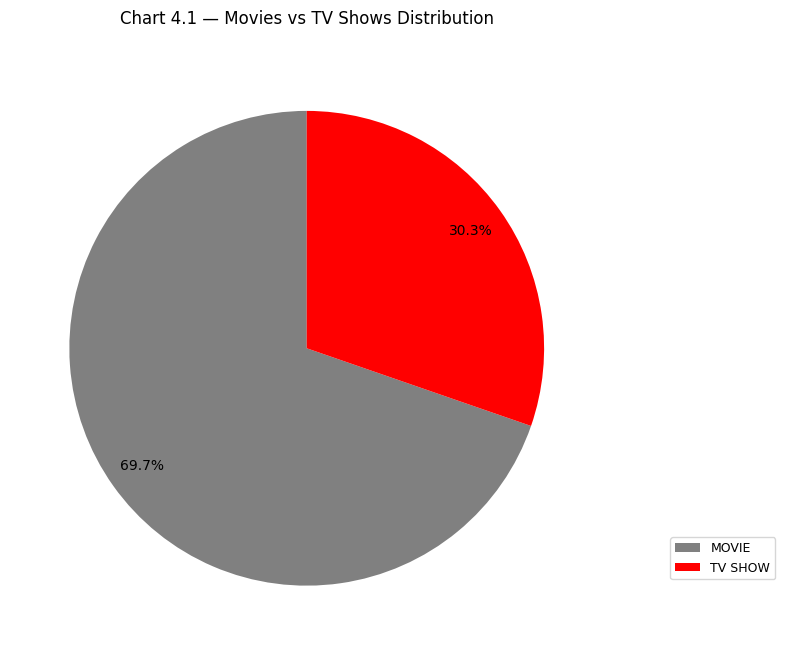

In [79]:
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(content_type, 
                                    labels=None,
                                    autopct='%1.1f%%',
                                    pctdistance=0.85,
                                    startangle=90,
                                    colors=['grey', 'red'])
plt.legend(wedges, content_type.index,
           loc='lower right',
           bbox_to_anchor=(1.3, 0.1),
           fontsize=9)
plt.title('Chart 4.1 — Movies vs TV Shows Distribution', pad=20)
plt.tight_layout()
plt.show()

**Finding:** Movies make up 69.7% of Netflix content while 
TV Shows account for 30.3%, confirming Netflix is primarily 
a movie platform.

### Content added by year (Barchart)

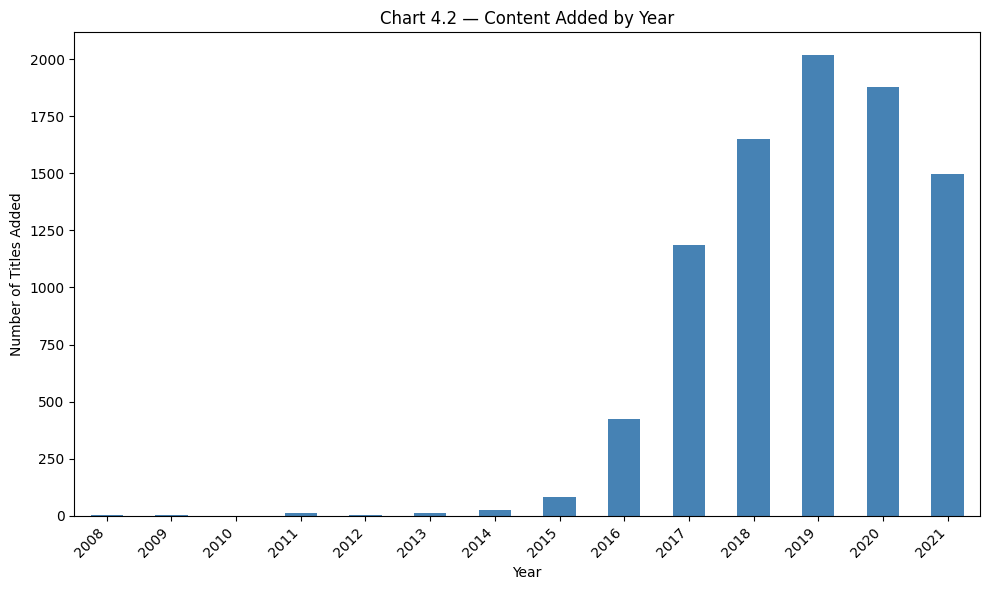

In [81]:
plt.figure(figsize=(10, 6))
content_by_year.plot(kind='bar', color='steelblue')
plt.title('Chart 4.2 — Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Netflix significantly increased content additions 
from 2016 onwards, peaking in 2019 with 2,016 titles added. 
A slight decline is seen in 2020 and 2021 possibly due to 
COVID-19 production slowdowns.

### Top 10 content producing countries (Barchart)

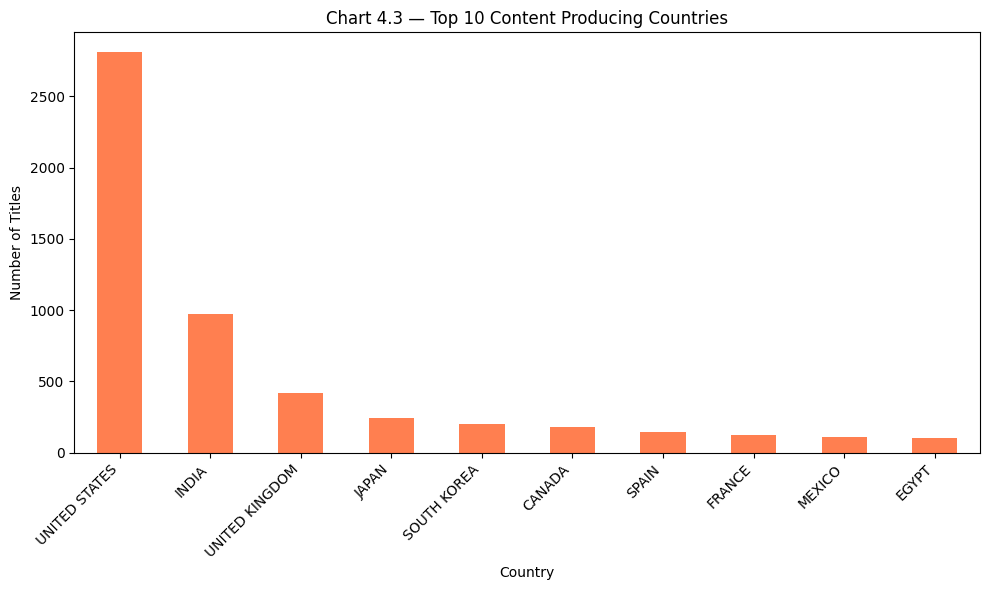

In [82]:
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='coral')
plt.title('Chart 4.3 — Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** United States dominates Netflix content production 
with 2,809 titles, followed by India with 972. This shows 
Netflix heavily relies on US and Indian content to fill its library.

### Most common ratings (Barchart)

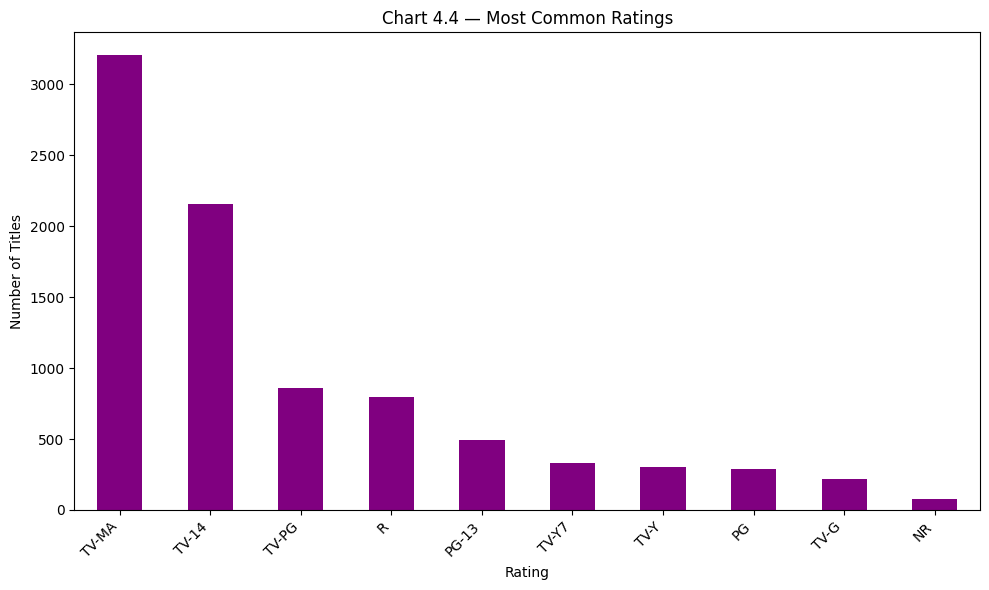

In [83]:
plt.figure(figsize=(10, 6))
top_ratings.plot(kind='bar', color='purple')
plt.title('Chart 4.4 — Most Common Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** TV-MA is the most common rating with 3,205 titles 
followed by TV-14 with 2,157 titles. This confirms Netflix 
primarily targets adult audiences with mature content.

### Top 10 most common genres (Barchart)

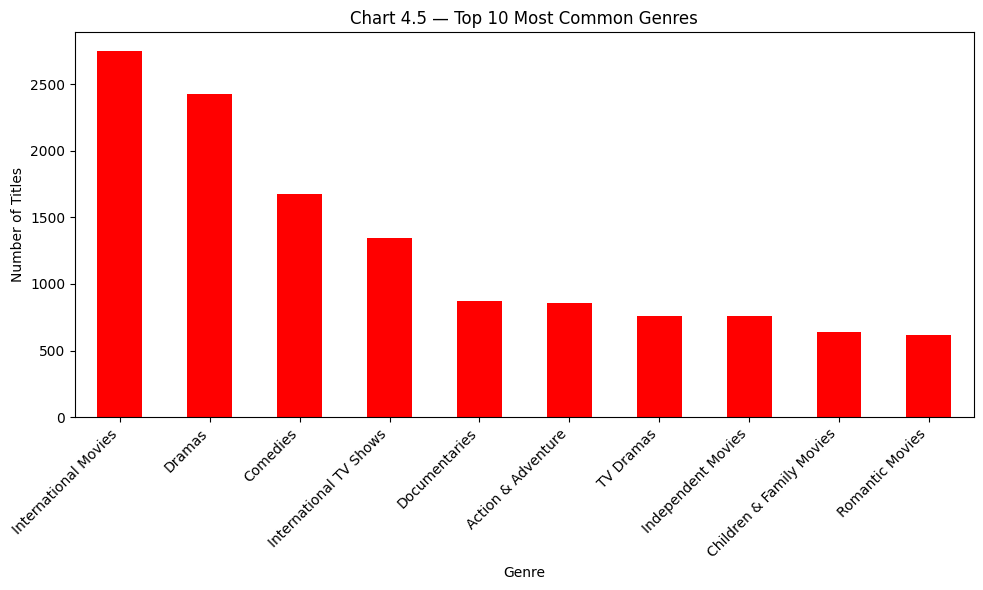

In [86]:
plt.figure(figsize=(10, 6))
genres.plot(kind='bar', color='red')
plt.title('Chart 4.5 — Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** International Movies and Dramas are the most common 
genres with 2,752 and 2,426 titles respectively, showing Netflix 
has a strong focus on international and dramatic content.

### Content added by year (Linechart)

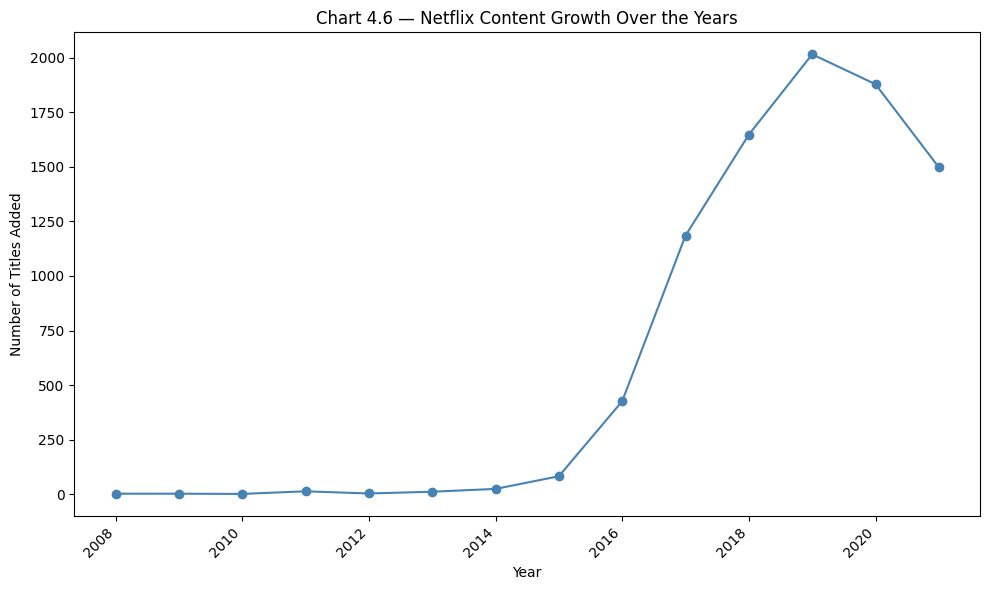

In [88]:
plt.figure(figsize=(10, 6))
content_by_year.plot(kind='line', color='steelblue', marker='o')
plt.title('Chart 4.6 — Netflix Content Growth Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** The line chart clearly shows Netflix's aggressive 
content expansion strategy from 2016 onwards, with a peak in 
2019 and a slight decline in 2020 and 2021.

### Distribution of release year (Histogram)

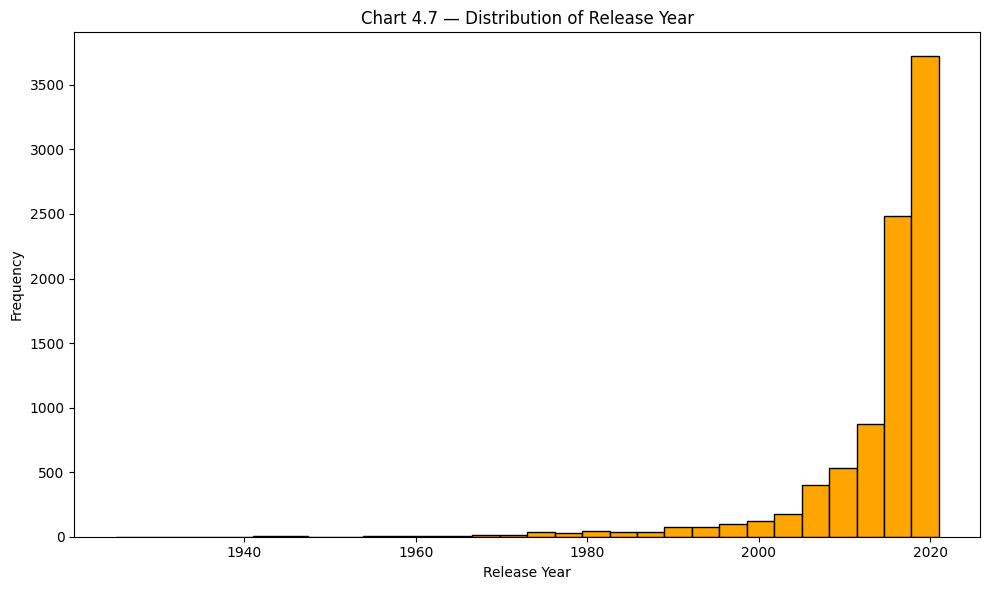

In [89]:
plt.figure(figsize=(10, 6))
df['release_year'].plot(kind='hist', bins=30, color='orange', edgecolor='black')
plt.title('Chart 4.7 — Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Finding:** The majority of Netflix content was released between 
2015 and 2021, confirming Netflix heavily favors recent content. 
Older titles from before 2000 are rare on the platform.

## Task-4 Summary

- Created 7 visualizations 
- Charts cover content type, yearly growth, countries, ratings and genres
- All charts have titles, axis labels and findings
- Charts are labelled Chart 4.1 through Chart 4.7 for easy reference in insights

# Task-5 Insights

### Insight 1 — Netflix is Primarily a Movie Platform
Movies make up 69.7% of all Netflix content compared to 30.3% 
for TV Shows. This suggests Netflix has historically focused 
more on acquiring and producing movies than TV shows, though 
TV shows are growing in popularity.
(Supported by: Chart 4.1)

### Insight 2 — Netflix Experienced Rapid Content Growth from 2016
Content additions grew dramatically from 426 titles in 2016 to 
2,016 titles in 2019. This aligns with Netflix's global expansion 
strategy. The slight decline in 2020 and 2021 is likely due to 
COVID-19 production slowdowns affecting content availability.
(Supported by: Chart 4.2 and Chart 4.6)

### Insight 3 — United States and India Dominate Content Production
The United States leads with 2,809 titles followed by India with 
972 titles. Together they account for the majority of Netflix 
content, showing Netflix relies heavily on these two markets 
for content production.
(Supported by: Chart 4.3)

### Insight 4 — Netflix Primarily Targets Adult Audiences
TV-MA and TV-14 are the two most common ratings with 3,205 and 
2,157 titles respectively. Combined they account for over 60% 
of all Netflix content, confirming the platform primarily 
targets adult and teenage audiences rather than children.
(Supported by: Chart 4.4)

### Insight 5 — International Content is a Core Part of Netflix
International Movies is the top genre with 2,752 titles, ahead 
of even Dramas at 2,426. This shows Netflix has made international 
content a core part of its library, catering to its global 
audience across different languages and cultures.
(Supported by: Chart 4.5)

In [91]:
df.to_csv(r'Data/netflix_cleaned.csv', index=False)